<a href="https://colab.research.google.com/github/AshenDary/NOEL-CCMACLRL-COM243/blob/main/Exercise1/Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [21]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [22]:
df = pd.read_csv('/personality_dataset.csv')

# Display the first 5 rows
print(df.head())

   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0                 3        Yes                        6              7   
1                 2         No                        8              6   
2                 1         No                        9              4   
3                 8         No                        0              0   
4                 5        Yes                        3              0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                   14               5   Extrovert  
1                        No                    7               8   Extrovert  
2                        No                    9               3   Extrovert  
3                       Yes                    9               3   Introvert  
4                        No                    2               6   Introvert  


Display the summary of all the features of the dataset using `.info()`

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


Display the total number of samples from each label using `.value_counts()`

In [24]:
df['Personality'].value_counts()

,count
Personality,
Introvert,2502
Extrovert,2498


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

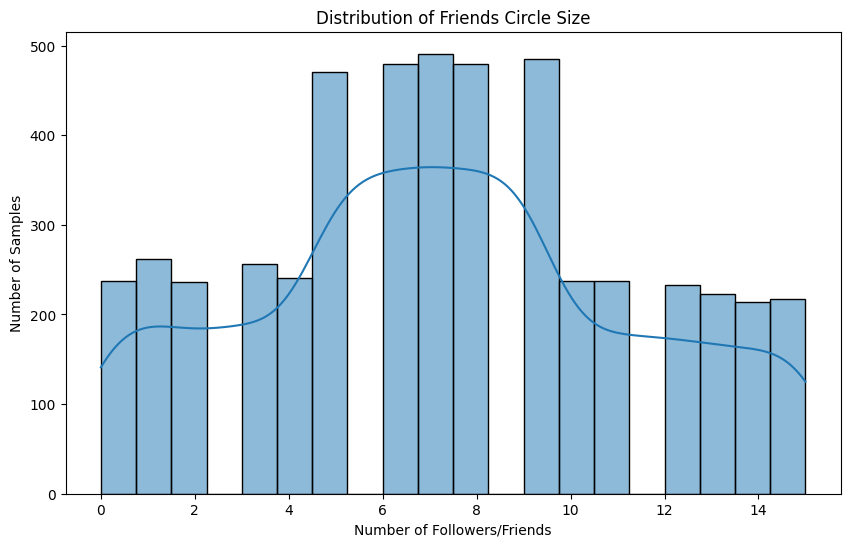

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Friends_circle_size'], bins=20, kde=True)
plt.title('Distribution of Friends Circle Size')
plt.xlabel('Number of Followers/Friends')
plt.ylabel('Number of Samples')
plt.show()

Remove the name column using `drop()` method

In [26]:
X = df.drop(columns=['Personality'])

## C. Split the dataset into training and test set

Convert the features into an numpy

1.   List item
2.   List item

array using `.values()` and store it in a variable "X"

In [27]:
X = pd.get_dummies(df.drop(columns=['Personality']), drop_first=True).values

# Display the array
print(X)

[[3 6 7 ... 5 True False]
 [2 8 6 ... 8 False False]
 [1 9 4 ... 3 False False]
 ...
 [2 7 3 ... 3 False False]
 [2 9 3 ... 7 True False]
 [4 6 7 ... 3 True False]]


Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [28]:
y = df['Personality'].values
print(y)

['Extrovert' 'Extrovert' 'Extrovert' ... 'Extrovert' 'Extrovert'
 'Extrovert']


Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split into training and test sets.")

Data successfully split into training and test sets.


Display the dimensions of each variables using `.shape()`

In [30]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4000, 7)
X_test shape: (1000, 7)
y_train shape: (4000,)
y_test shape: (1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [31]:
knn = KNeighborsClassifier()
print("KNN Classifier.")

KNN Classifier.


Train the model using the `.fit()`

In [32]:
knn.fit(X_train, y_train)
print("Model trained")

Model trained


Test the model using the `.predict()`

In [33]:
y_pred = knn.predict(X_test)
print(y_pred[:10])

['Extrovert' 'Extrovert' 'Introvert' 'Extrovert' 'Extrovert' 'Extrovert'
 'Extrovert' 'Introvert' 'Extrovert' 'Introvert']


## E. Evaluate the model

Create a confusion matrix

> Add blockquote



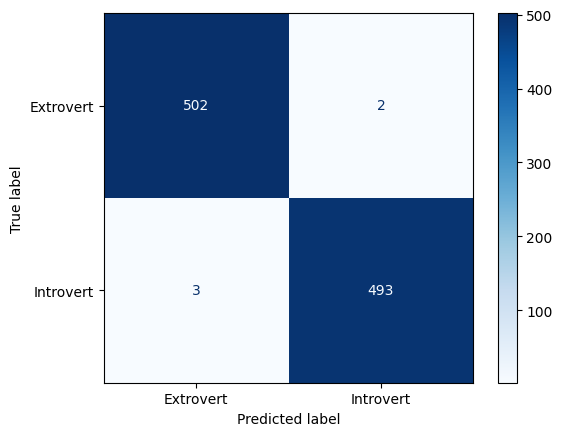

In [34]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

Display the accuracy

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2%}")

Accuracy Score: 99.50%


Display the precision

In [36]:
precision = precision_score(y_test, y_pred, pos_label='Extrovert')
print(f"Precision Score: {precision:.2%}")

Precision Score: 99.41%


Display the recall

In [37]:
recall = recall_score(y_test, y_pred, pos_label='Extrovert')
print(f"Recall Score: {recall:.2%}")

Recall Score: 99.60%


Display the f1-score

In [38]:
f1 = f1_score(y_test, y_pred, pos_label='Extrovert')
print(f"F1-score: {f1:.2%}")

F1-score: 99.50%


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [39]:
import numpy as np

my_features = np.array([[2, 6, 9, 10, 1, False, False]])

prediction = knn.predict(my_features)
print(f"Based on my features, the model predicts: {prediction[0]}")

Based on my features, the model predicts: Extrovert
